<a href="https://colab.research.google.com/github/nora-mohamed25/data-analysis-portfolio/blob/main/Project_09_yield_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# yield  data

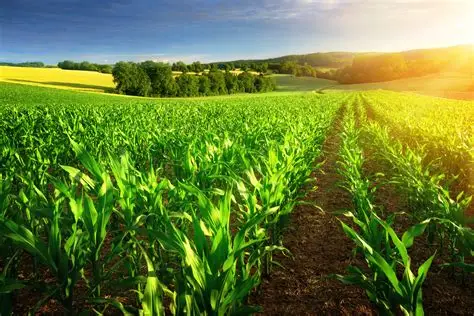

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
df = pd.read_excel('/content/crop yield data sheet.xlsx')

In [ ]:
df.head()

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Fertilizer      99 non-null     float64
 2   Temperatue      100 non-null    object 
 3   Nitrogen (N)    99 non-null     float64
 4   Phosphorus (P)  99 non-null     float64
 5   Potassium (K)   99 non-null     float64
 6   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(6), object(1)
memory usage: 6.1+ KB


In [ ]:
df.describe()

,Rain Fall (mm),Fertilizer,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,849.797980,67.808081,70.737374,21.131313,18.060606,9.050505
std,400.042676,10.028202,6.677079,1.951695,1.817254,1.965902
min,400.000000,50.000000,59.000000,18.000000,15.000000,5.500000
25%,450.000000,60.000000,65.000000,19.500000,16.000000,7.000000
50%,1150.000000,70.000000,71.000000,21.000000,19.000000,9.000000
75%,1237.500000,77.000000,77.000000,23.000000,19.000000,11.000000
max,1300.000000,80.000000,80.000000,25.000000,22.000000,12.000000


In [ ]:
df.rename(columns={
    'Temperatue': 'Temperature',
    'Yeild (Q/acre)': 'Yield (Q/acre)'
}, inplace=True)

In [ ]:
df['Temperature'].unique()

array([28, 36, 29, 35, 27, 34, 37, 39, 26, 38, 24, 25, 40, nan, ':'],
      dtype=object)

In [ ]:
df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')

In [ ]:
df.isnull().sum()

,0
Rain Fall (mm),10
Fertilizer,10
Temperature,10
Nitrogen (N),10
Phosphorus (P),10
Potassium (K),10
Yield (Q/acre),10


In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109 entries, 0 to 108
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  109 non-null    float64
 1   Fertilizer      109 non-null    float64
 2   Temperature     109 non-null    float64
 3   Nitrogen (N)    109 non-null    float64
 4   Phosphorus (P)  109 non-null    float64
 5   Potassium (K)   109 non-null    float64
 6   Yield (Q/acre)  109 non-null    float64
dtypes: float64(7)
memory usage: 6.1 KB


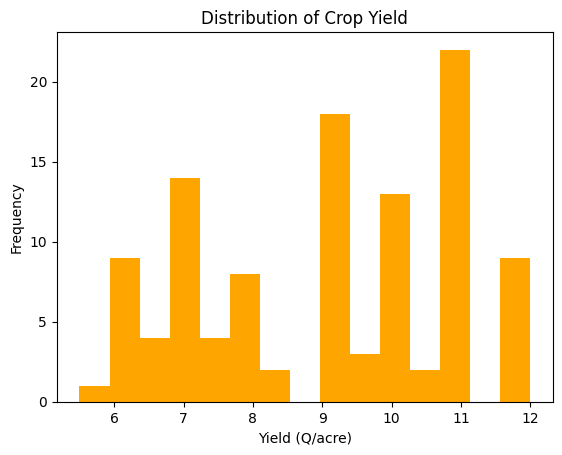

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['Yield (Q/acre)'], bins=15, color='Orange')
plt.xlabel('Yield (Q/acre)')
plt.ylabel('Frequency')
plt.title('Distribution of Crop Yield')
plt.show()

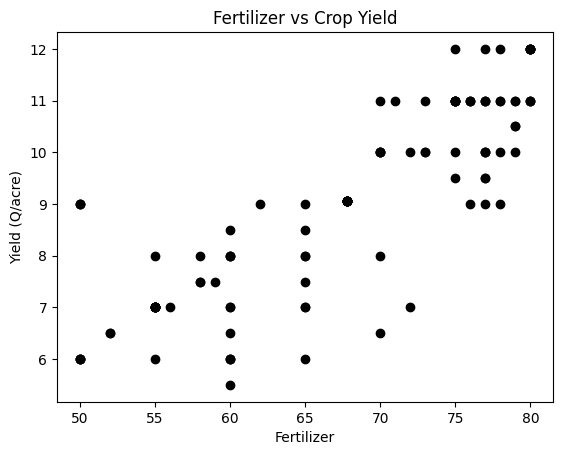

In [ ]:
plt.scatter(df['Fertilizer'], df['Yield (Q/acre)'], color='black')
plt.xlabel('Fertilizer')
plt.ylabel('Yield (Q/acre)')
plt.title('Fertilizer vs Crop Yield')
plt.show()

/tmp/ipython-input-557200413.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Rainfall_Level')['Yield (Q/acre)'].mean().plot(


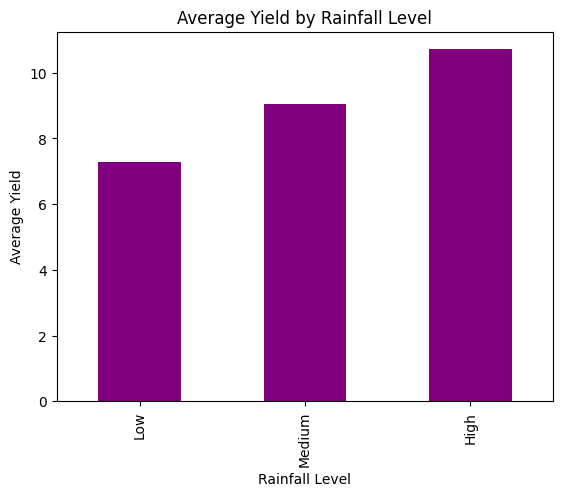

In [ ]:
df['Rainfall_Level'] = pd.cut(
    df['Rain Fall (mm)'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

df.groupby('Rainfall_Level')['Yield (Q/acre)'].mean().plot(
    kind='bar',
    color='purple'
)

plt.xlabel('Rainfall Level')
plt.ylabel('Average Yield')
plt.title('Average Yield by Rainfall Level')
plt.show()

In [ ]:
X = df.drop(['Yield (Q/acre)', 'Rainfall_Level'], axis=1)
y = df['Yield (Q/acre)']

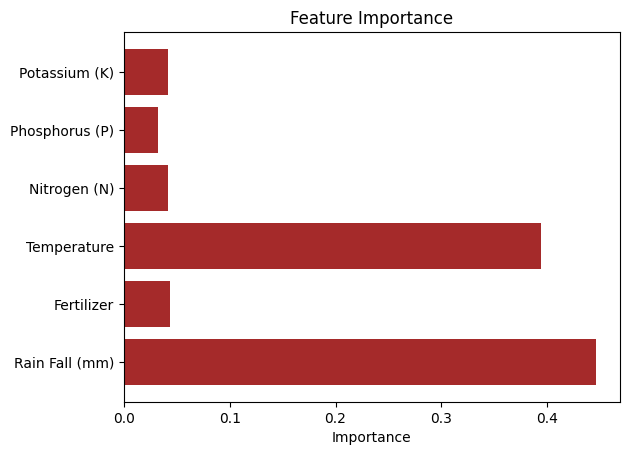

In [ ]:
importances = rf.feature_importances_

plt.barh(X_train.columns, importances, color='brown')
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


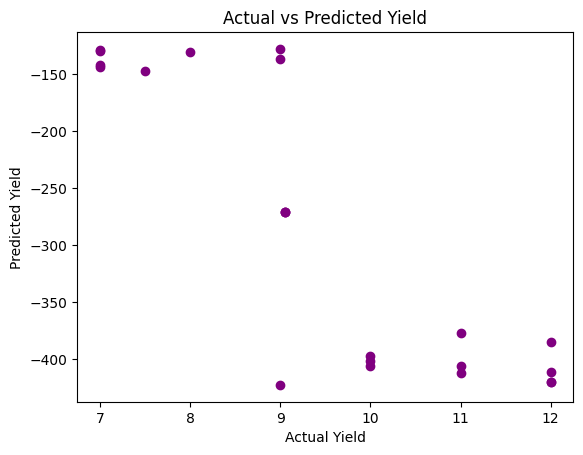

In [ ]:
y_pred = lr.predict(X_test)

plt.scatter(y_test, y_pred, color='purple')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs Predicted Yield')
plt.show()

In [ ]:
print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MSE: 0.6135169457201566
R2: 0.7926690495875162


In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_test)

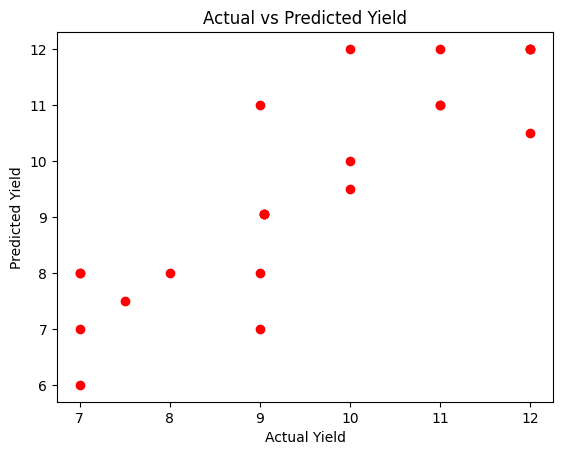

In [ ]:
y_pred = dt.predict(X_test)

plt.scatter(y_test, y_pred, color='red')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs Predicted Yield')
plt.show()

In [ ]:
print("Decision Tree")
print("MSE:", mean_squared_error(y_test, y_pred_lr))
print("R2:", r2_score(y_test, y_pred_lr))

Decision Tree
MSE: 0.6135169457201566
R2: 0.7926690495875162


In [ ]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

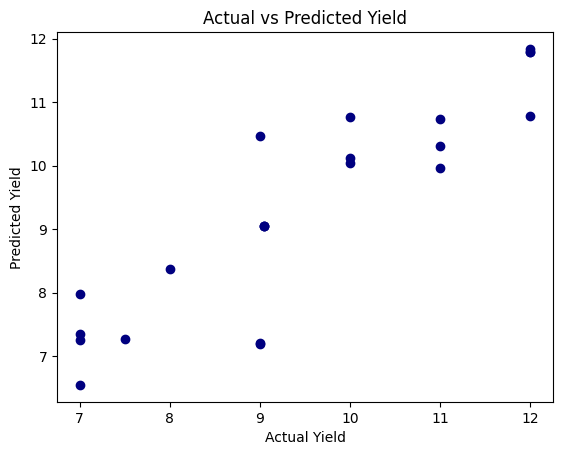

In [ ]:
y_pred = rf.predict(X_test)

plt.scatter(y_test, y_pred, color='navy')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs Predicted Yield')
plt.show()

In [ ]:
print("Random Forest")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
MSE: 0.6362007665324041
R2: 0.7850033149068396


In [ ]:
estimators = [('lr', lr), ('dt', dt), ('rf', rf)]
ensemble = VotingRegressor(estimators=estimators)
ensemble.fit(X_train, y_train)

VotingRegressor(estimators=[('lr', LinearRegression()),
                            ('dt', DecisionTreeRegressor(random_state=42)),
                            ('rf', RandomForestRegressor(random_state=42))])

In [ ]:
y_pred_ensemble = ensemble.predict(X_test)

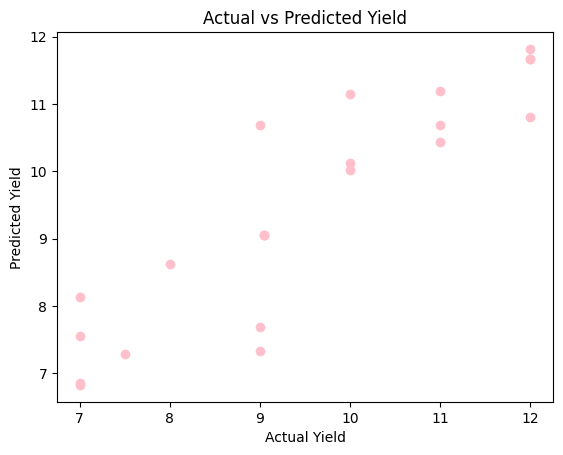

In [ ]:
y_pred = ensemble.predict(X_test)

plt.scatter(y_test, y_pred, color='pink')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.title('Actual vs Predicted Yield')
plt.show()

In [ ]:
print("Ensemble")
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2:", r2_score(y_test, y_pred_rf))

Ensemble
MSE: 0.6362007665324041
R2: 0.7850033149068396
